# Electric Vehicle Adoption and Distribution in Washington State

## 1. Introduction and Research Questions

Electric vehicles are becoming an increasingly important part of the transportation system. This project examines the geographic and market distribution of registered electric vehicles, primarily in Washington State. The analysis uses vehicle registration data containing information about vehicle location, manufacturer, model, model year, electric-vehicle type, electric range, and clean-fuel eligibility.

The project addresses the following research questions:

1. Which Washington counties and cities have the largest numbers of registered electric vehicles?
2. Which manufacturers and vehicle models are most common?
3. What proportion of registered vehicles are battery-electric vehicles versus plug-in hybrid vehicles?
4. How does electric-vehicle composition differ across counties?
5. How are model year, electric range, and clean-fuel eligibility related to vehicle type?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv ("/Users/carolinekinya/Downloads/export.csv")

In [5]:
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294188,YV1H60EP7P,Jefferson,Port Townsend,WA,98368.0,2023,VOLVO,V60,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,41.0,24.0,236211300,POINT (-122.77263 48.1212),BONNEVILLE POWER ADMINISTRATION||PUGET SOUND E...,5.303195e+10
294189,5YJ3E1EB3L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,14.0,292558003,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
294190,KNDCR3L13S,King,Seattle,WA,98118.0,2025,KIA,NIRO,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,282972294,POINT (-122.28083 47.54693),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
294191,JTDKARFP0H,Pierce,Lakewood,WA,98499.0,2017,TOYOTA,PRIUS PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,28.0,168423146,POINT (-122.51495 47.16196),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10


In [6]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,294183.000000,294193.000000,294180.000000,293431.000000,2.941930e+05,2.941830e+05
mean,98176.263231,2022.312665,36.922578,28.766582,2.504942e+08,5.296843e+10
std,2644.315758,3.085205,76.309809,14.892012,6.244728e+07,1.674636e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.278658e+08,5.303301e+10
50%,98134.000000,2023.000000,0.000000,32.000000,2.675898e+08,5.303303e+10
75%,98390.000000,2024.000000,32.000000,42.000000,2.834127e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [7]:
df.dtypes

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294193 entries, 0 to 294192
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         294193 non-null  object 
 1   County                                             294183 non-null  object 
 2   City                                               294183 non-null  object 
 3   State                                              294193 non-null  object 
 4   Postal Code                                        294183 non-null  float64
 5   Model Year                                         294193 non-null  int64  
 6   Make                                               294193 non-null  object 
 7   Model                                              294193 non-null  object 
 8   Electric Vehicle Type                              294193 non-null  object

In [9]:
df.shape

(294193, 16)

In [10]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10


In [11]:
df.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
294188,YV1H60EP7P,Jefferson,Port Townsend,WA,98368.0,2023,VOLVO,V60,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,41.0,24.0,236211300,POINT (-122.77263 48.1212),BONNEVILLE POWER ADMINISTRATION||PUGET SOUND E...,5.303195e+10
294189,5YJ3E1EB3L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,14.0,292558003,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
294190,KNDCR3L13S,King,Seattle,WA,98118.0,2025,KIA,NIRO,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,282972294,POINT (-122.28083 47.54693),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
294191,JTDKARFP0H,Pierce,Lakewood,WA,98499.0,2017,TOYOTA,PRIUS PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,28.0,168423146,POINT (-122.51495 47.16196),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
294192,5YJ3E1EA6L,Snohomish,Bothell,WA,98021.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,1.0,137123871,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10


In [12]:
df.columns.tolist()

['VIN (1-10)',
 'County',
 'City',
 'State',
 'Postal Code',
 'Model Year',
 'Make',
 'Model',
 'Electric Vehicle Type',
 'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
 'Electric Range',
 'Legislative District',
 'DOL Vehicle ID',
 'Vehicle Location',
 'Electric Utility',
 '2020 Census Tract']

In [13]:
###  Missing Data

####Missing-data analysis identifies variables that may require cleaning or special treatment before they are used in calculationsor visualizations.

missing_data = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_data = missing_data.sort_values(
    "Missing Values",
    ascending=False
)

missing_data

,Missing Values,Missing Percentage
Legislative District,762,0.26
Vehicle Location,18,0.01
Electric Range,13,0.00
County,10,0.00
City,10,0.00
Postal Code,10,0.00
Electric Utility,10,0.00
2020 Census Tract,10,0.00
VIN (1-10),0,0.00
State,0,0.00


In [14]:
missing_only = missing_data[
    missing_data["Missing Values"] > 0
]

missing_only

,Missing Values,Missing Percentage
Legislative District,762,0.26
Vehicle Location,18,0.01
Electric Range,13,0.00
County,10,0.00
City,10,0.00
Postal Code,10,0.00
Electric Utility,10,0.00
2020 Census Tract,10,0.00


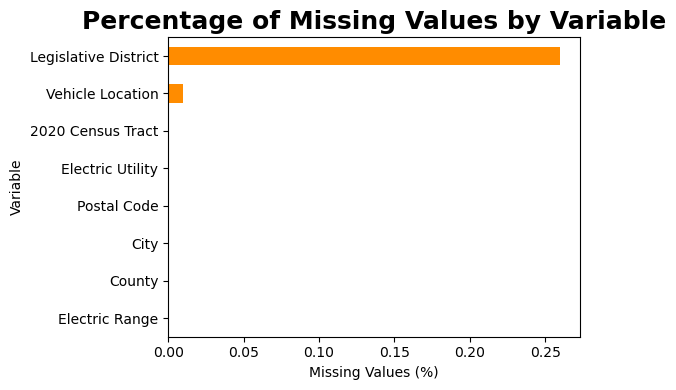

In [15]:
missing_only["Missing Percentage"].sort_values().plot(
    kind="barh",
    figsize=(6, 4),
    color="darkorange",
    legend=False
)

plt.title(
    "Percentage of Missing Values by Variable",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

###  Data Limitations

The dataset has several limitations that affect its interpretation.

First, it represents registered electric vehicles rather than annual vehicle sales. Therefore, counts by model year should not be interpreted as the number of vehicles sold or registered during each year.

Second, approximately 99.7% of the records are from Washington State. The dataset should therefore be treated primarily as a Washington State dataset rather than a national electric-vehicle dataset.

Third, many records have an electric range of zero. A zero value does not necessarily indicate that the vehicle has no electric range. 
In many cases, it means that the battery range has not been researched or recorded. Range analysis should therefore be limited to vehicles with a recorded range greater than zero.

Fourth, the dataset reports the number of registered vehicles, but it does not contain population or household data. County comparisons represent total vehicle counts rather than per-capita electric-vehicle adoption rates. More populated counties may have higher counts partly because they have more residents.

Fifth, vehicle model year is not the same as registration year. The dataset cannot directly measure annual growth in EV registration without a registration-date variable.

Finally, the dataset does not contain information about vehicle prices, owner income, race, age, charging access, or reasons for purchasing an electric vehicle. It can describe geographic and market patterns but cannot explain individual purchasing decisions.

### Cleaning Column Names

The original column names contain capital letters, spaces, parentheses, and other special characters. 
They are converted to lowercase snake_case names to make them easier to reference consistently in Python.

In [16]:
df = df.rename(
    columns={
        "2020 Census Tract": "Census Tract 2020",
        "Postal_Code": "Postal Code"
    }
)

In [17]:
df.columns.tolist()

['VIN (1-10)',
 'County',
 'City',
 'State',
 'Postal Code',
 'Model Year',
 'Make',
 'Model',
 'Electric Vehicle Type',
 'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
 'Electric Range',
 'Legislative District',
 'DOL Vehicle ID',
 'Vehicle Location',
 'Electric Utility',
 'Census Tract 2020']

In [18]:
text_columns = [
    "State",
    "County",
    "City"
]

for column in text_columns:
    df[column] = (
        df[column]
          .astype("string")
          .str.strip()
    )

In [19]:
df[["State", "County", "City"]]

,State,County,City
0,WA,Yakima,Yakima
1,WA,Thurston,Olympia
2,WA,Kitsap,Kingston
3,WA,King,Seattle
4,WA,Yakima,Yakima
...,...,...,...
294188,WA,Jefferson,Port Townsend
294189,WA,Yakima,Yakima
294190,WA,King,Seattle
294191,WA,Pierce,Lakewood


In [20]:
df["Postal Code"] = (
    pd.to_numeric(
        df["Postal Code"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
    .str.zfill(5)
)

df["Postal Code"].head()

0    98908
1    98502
2    98346
3    98107
4    98902
Name: Postal Code, dtype: string

In [21]:
####Correct census tracts

df["Census Tract 2020"] = (
    pd.to_numeric(
        df["Census Tract 2020"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
    .str.zfill(11)
)
df["Census Tract 2020"].head()

0    53077001000
1    53067011100
2    53035090102
3    53033003400
4    53077001202
Name: Census Tract 2020, dtype: string

In [22]:
df["Census Tract 2020"].str.len().value_counts(
    dropna=False
)

Census Tract 2020
11      294183
<NA>        10
Name: count, dtype: Int64

In [23]:
#### Correct legislative districts

df["Legislative District"] = (
    pd.to_numeric(
        df["Legislative District"],
        errors="coerce"
    )
    .astype("Int64")
)


In [24]:
#### Check geographic values

print("Number of states:", df["State"].nunique())
print("Number of counties:", df["County"].nunique())
print("Number of cities:", df["City"].nunique())
print("Number of postal codes:", df["Postal Code"].nunique())
print("Number of census tracts:", df["Census Tract 2020"].nunique())

Number of states: 52
Number of counties: 257
Number of cities: 941
Number of postal codes: 1189
Number of census tracts: 2445


###  Cleaning Electric Range

Electric range is stored as a numeric variable. However, many records have an electric range of zero because their battery range has not been researched or recorded. These values should not be interpreted as vehicles with no electric range. 
The original variable is retained, and a separate cleaned variable is created for range analysis.

In [25]:
df["Electric Range"].describe()

count    294180.000000
mean         36.922578
std          76.309809
min           0.000000
25%           0.000000
50%           0.000000
75%          32.000000
max         337.000000
Name: Electric Range, dtype: float64

In [26]:
print(
    "Zero range values:",
    f"{(df['Electric Range'] == 0).sum():,}"
)

print(
    "Missing range values:",
    f"{df['Electric Range'].isna().sum():,}"
)

Zero range values: 192,477
Missing range values: 13


In [27]:
df["Range Recorded"] = (
    df["Electric Range"].notna()
    & df["Electric Range"].gt(0)
)

In [28]:
import numpy as np

df["Electric Range Clean"] = np.where(
    df["Electric Range"] > 0,
    df["Electric Range"],
    np.nan
)

In [29]:
df[
    [
        "Electric Range",
        "Range Recorded",
        "Electric Range Clean"
    ]
].head(10)

,Electric Range,Range Recorded,Electric Range Clean
0,266.0,True,266.0
1,220.0,True,220.0
2,208.0,True,208.0
3,258.0,True,258.0
4,220.0,True,220.0
5,73.0,True,73.0
6,84.0,True,84.0
7,84.0,True,84.0
8,0.0,False,NaN
9,322.0,True,322.0


In [30]:
df[
    [
        "Electric Range",
        "Electric Range Clean"
    ]
].describe()

,Electric Range,Electric Range Clean
count,294180.000000,101703.000000
mean,36.922578,106.800035
std,76.309809,96.855157
min,0.000000,1.000000
25%,0.000000,30.000000
50%,0.000000,47.000000
75%,32.000000,215.000000
max,337.000000,337.000000


In [31]:
df["Electric Range Clean"]

0         266.0
1         220.0
2         208.0
3         258.0
4         220.0
          ...  
294188     41.0
294189    322.0
294190      NaN
294191     25.0
294192    266.0
Name: Electric Range Clean, Length: 294193, dtype: float64

In [32]:
range_by_type = (
    df.groupby("Electric Vehicle Type")
      ["Electric Range Clean"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(1)
)

range_by_type

,count,mean,median,min,max
Electric Vehicle Type,,,,,
Battery Electric Vehicle (BEV),45090,200.5,215.0,29.0,337.0
Plug-in Hybrid Electric Vehicle (PHEV),56613,32.2,32.0,1.0,153.0


### Checking Duplicate Vehicles

Duplicate records can cause vehicle totals to be overstated. The DOL Vehicle ID is used as the principal vehicle-record identifier.
The abbreviated VIN is not used by itself because it contains only the first ten characters and may therefore appear in multiple records.

In [33]:
print("Total rows:", f"{len(df):,}")

print(
    "Unique DOL Vehicle IDs:",
    f"{df['DOL Vehicle ID'].nunique():,}"
)

Total rows: 294,193
Unique DOL Vehicle IDs: 294,193


In [34]:
duplicate_id_count = df.duplicated(
    subset="DOL Vehicle ID",
    keep=False
).sum()

print(
    "Rows with duplicated DOL Vehicle IDs:",
    f"{duplicate_id_count:,}"
)

Rows with duplicated DOL Vehicle IDs: 0


In [35]:
duplicate_vehicles = (
    df[df.duplicated(
        subset="DOL Vehicle ID",
        keep=False
    )]
    .sort_values("DOL Vehicle ID")
)

duplicate_vehicles.head(20)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,Census Tract 2020,Range Recorded,Electric Range Clean


In [36]:
print("Total rows:", len(df))
print("Unique DOL Vehicle IDs:", df["DOL Vehicle ID"].nunique())

Total rows: 294193
Unique DOL Vehicle IDs: 294193


In [37]:
exact_duplicates = df.duplicated().sum()

print(
    "Completely duplicated rows:",
    f"{exact_duplicates:,}"
)

Completely duplicated rows: 0


In [38]:
print(
    "Unique abbreviated VINs:",
    f"{df['VIN (1-10)'].nunique():,}"
)

print(
    "Duplicated abbreviated VIN rows:",
    f"{df.duplicated('VIN (1-10)', keep=False).sum():,}"
)

Unique abbreviated VINs: 18,068
Duplicated abbreviated VIN rows: 290,799


In [39]:
EV_Clean = df.copy()

In [40]:
WA_EV_Clean = (
    EV_Clean[
        EV_Clean["State"] == "WA"
    ]
    .copy()
)

print(
    "Final Washington analytical records:",
    f"{len(WA_EV_Clean):,}"
)

Final Washington analytical records: 293,432


### 4.1 Electric Vehicles by County

This subsection identifies the Washington counties with the largest numbers of registered electric vehicles and calculates each county's share of the statewide dataset.

In [41]:
county_counts = (
    WA_EV_Clean["County"]
    .value_counts()
)
county_counts.head(10)

County
King         141971
Snohomish     37128
Pierce        24578
Clark         18346
Thurston      10806
Kitsap        10185
Spokane        8503
Whatcom        7357
Benton         4382
Skagit         3504
Name: count, dtype: Int64

In [42]:
county_summary = pd.DataFrame({
    "Number of Vehicles": county_counts,
    "Percentage of WA Vehicles": (
        county_counts
        / len(WA_EV_Clean)
        * 100
    ).round(1)
})

county_summary.head(10)

,Number of Vehicles,Percentage of WA Vehicles
County,,
King,141971,48.4
Snohomish,37128,12.7
Pierce,24578,8.4
Clark,18346,6.3
Thurston,10806,3.7
Kitsap,10185,3.5
Spokane,8503,2.9
Whatcom,7357,2.5
Benton,4382,1.5


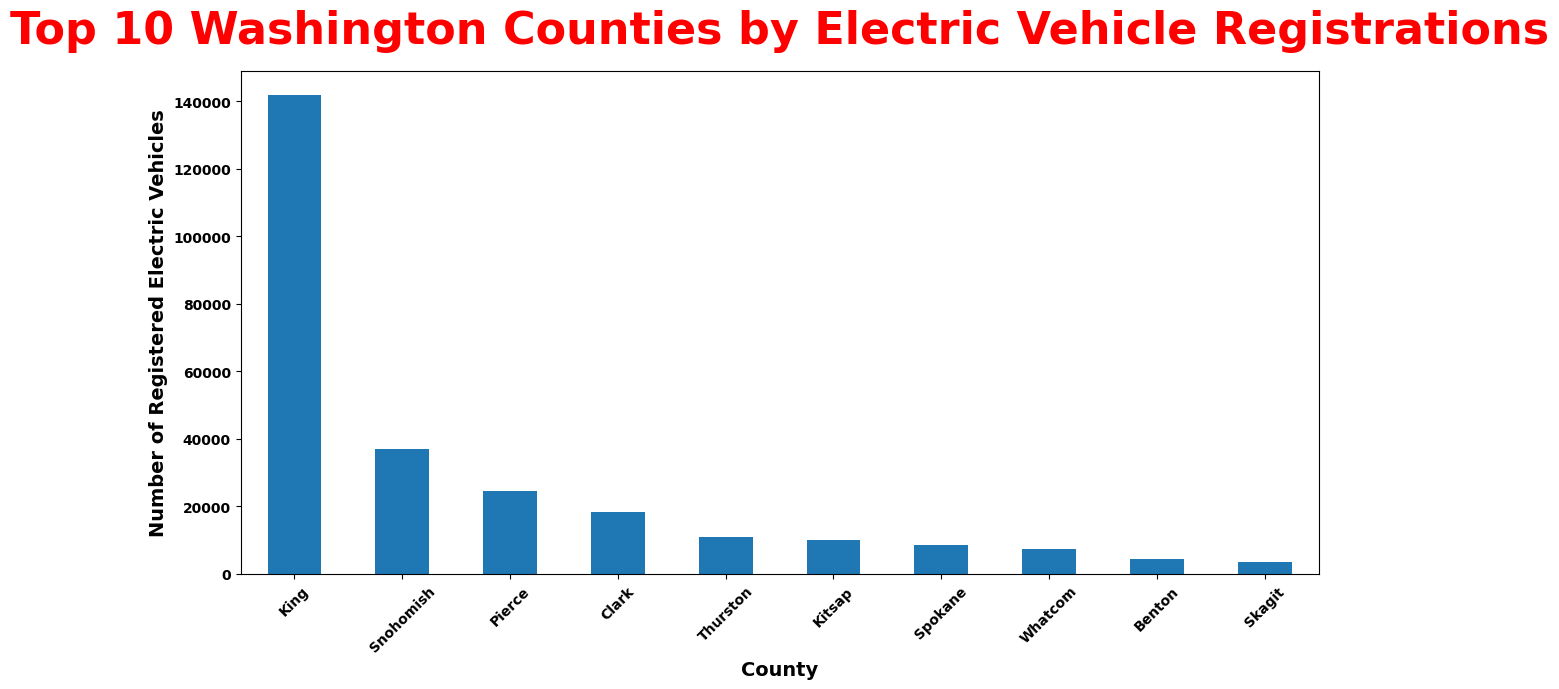

In [43]:
#Geographic Distribution of Electric Vehicles
##Where are electric vehicles concentrated in Washington State?
### Total EVs by county

county_counts = df["County"].value_counts().head(10)

county_counts.plot(
    kind="bar",
    figsize=(12, 7)
)
plt.title("Top 10 Washington Counties by Electric Vehicle Registrations",
    fontsize=32,
    fontweight="bold",
    color="red",
    pad=20
)
plt.xlabel('County', fontsize=14, fontweight="bold")
plt.ylabel('Number of Registered Electric Vehicles', fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontweight="bold")
plt.yticks(rotation=0, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Electric Vehicles by City

This subsection identifies the Washington cities with the largest numbers of registered electric vehicles. City-level results provide a more detailed picture of geographic concentration than county totals.

In [44]:
city_counts = (
    WA_EV_Clean["City"]
    .value_counts()
)

city_counts.head(10)

City
Seattle      44697
Bellevue     14148
Vancouver    10969
Redmond       9978
Bothell       9618
Kirkland      8336
Sammamish     8022
Renton        7799
Olympia       6916
Tacoma        6539
Name: count, dtype: Int64

In [45]:
city_summary = pd.DataFrame({
    "Number of Vehicles": city_counts,
    "Percentage of WA Vehicles": (
        city_counts
        / len(WA_EV_Clean)
        * 100
    ).round(1)
})

city_summary.head(10)

,Number of Vehicles,Percentage of WA Vehicles
City,,
Seattle,44697,15.2
Bellevue,14148,4.8
Vancouver,10969,3.7
Redmond,9978,3.4
Bothell,9618,3.3
Kirkland,8336,2.8
Sammamish,8022,2.7
Renton,7799,2.7
Olympia,6916,2.4


In [46]:
city_county_counts = (
    WA_EV_Clean
    .groupby(["City", "County"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Number of Vehicles")
)

city_county_counts.head(10)

,City,County,Number of Vehicles
0,Seattle,King,44697
1,Bellevue,King,14148
2,Vancouver,Clark,10969
3,Redmond,King,9978
4,Kirkland,King,8336
5,Sammamish,King,8022
6,Renton,King,7799
7,Bothell,Snohomish,7561
8,Olympia,Thurston,6914
9,Tacoma,Pierce,6539


In [47]:
top_cities = city_county_counts.head(10).copy()

top_cities["Location"] = (
    top_cities["City"]
    + ", "
    + top_cities["County"]
    + " County"
)

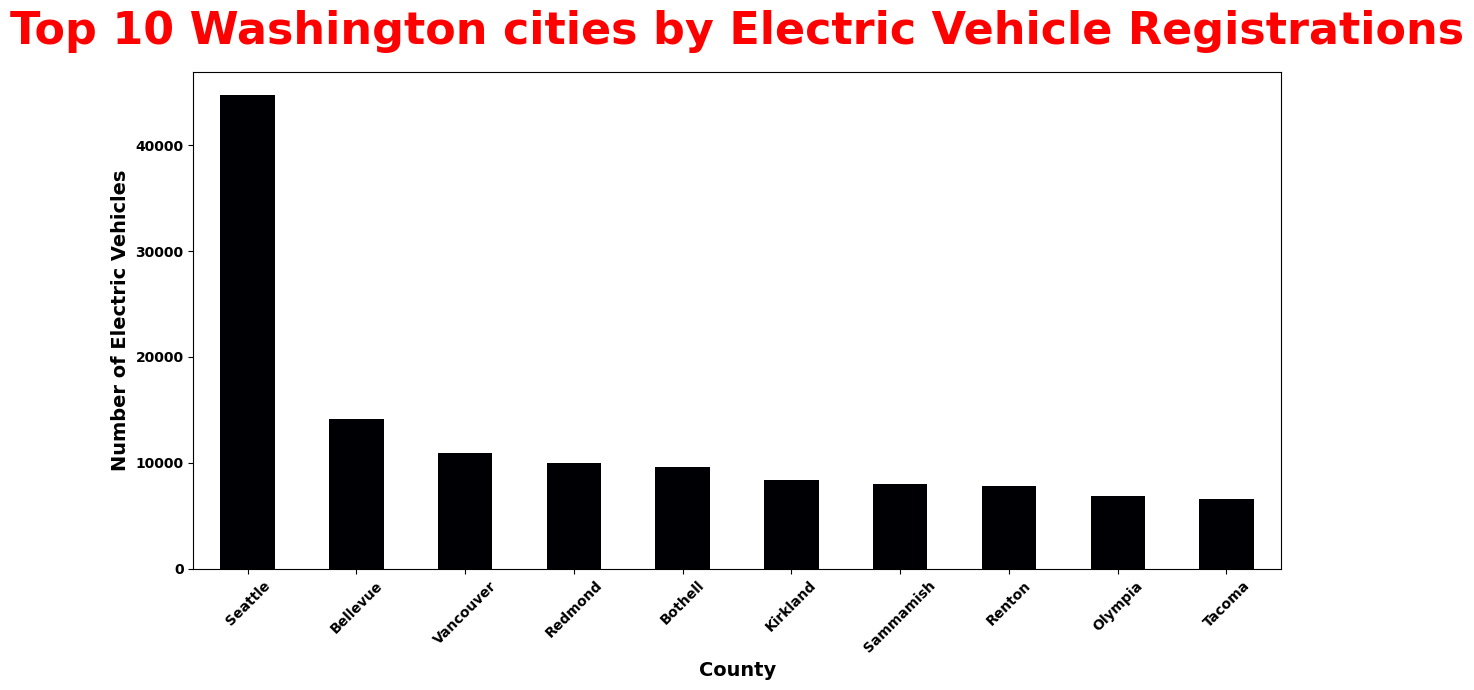

In [48]:
###Total EVs by city
city_counts = df["City"].value_counts().head(10)

city_counts.plot(
    kind="bar",
    figsize=(12, 7),
    cmap='magma',                 # Colormap ('viridis', 'plasma', 'magma', 'coolwarm')
)
plt.title("Top 10 Washington cities by Electric Vehicle Registrations",
    fontsize=32,
    fontweight="bold",
    color="red",
    pad=20
)
plt.xlabel('County', fontsize=14, fontweight="bold")
plt.ylabel('Number of Electric Vehicles', fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontweight="bold")
plt.yticks(rotation=0, fontweight="bold")
plt.tight_layout()
plt.show()

The city analysis provides a more detailed view of registration concentration. As with the county analysis, the results show total registrations rather than per-capita adoption. Large cities may rank highly because they have larger populations.

### 4.3 Electric Vehicles by Legislative District

This subsection compares the number of registered electric vehicles across Washington legislative districts. Legislative districts provide a policy-relevant geographic unit for understanding how EV registrations are distributed across political constituencies.

In [49]:
print(
    "Missing legislative districts:",
    f"{WA_EV_Clean['Legislative District'].isna().sum():,}"
)

Missing legislative districts: 1


In [50]:
WA_EV_Clean["Legislative District"] = (
    pd.to_numeric(
        WA_EV_Clean["Legislative District"],
        errors="coerce"
    )
    .astype("Int64")
)

In [51]:
district_counts = (
    WA_EV_Clean["Legislative District"]
    .value_counts(dropna=False)
    .sort_index()
)

district_counts

Legislative District
1       12736
2        3830
3        1587
4        2674
5       12401
6        3141
7        1679
8        3663
9        2092
10       5446
11       9012
12       3105
13       2467
14       2167
15        983
16       1881
17       5343
18       8232
19       1903
20       2919
21       7693
22       7187
23       6359
24       4144
25       3482
26       6167
27       4224
28       3924
29       2337
30       3788
31       5661
32       7110
33       5491
34       8050
35       4517
36      10839
37       8182
38       3560
39       4840
40       6117
41      17696
42       4368
43       9398
44       8494
45      16349
46      10605
47       5902
48      15385
49       4301
<NA>        1
Name: count, dtype: Int64

In [52]:
valid_district_counts = (
    WA_EV_Clean["Legislative District"]
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

valid_district_counts.head(10)

Legislative District
41    17696
45    16349
48    15385
1     12736
5     12401
36    10839
46    10605
43     9398
11     9012
44     8494
Name: count, dtype: Int64

In [53]:
district_summary = pd.DataFrame({
    "Number of Vehicles": valid_district_counts,
    "Percentage of WA Vehicles": (
        valid_district_counts
        / len(WA_EV_Clean)
        * 100
    ).round(1)
})

district_summary.head(10)

,Number of Vehicles,Percentage of WA Vehicles
Legislative District,,
41,17696,6.0
45,16349,5.6
48,15385,5.2
1,12736,4.3
5,12401,4.2
36,10839,3.7
46,10605,3.6
43,9398,3.2
11,9012,3.1


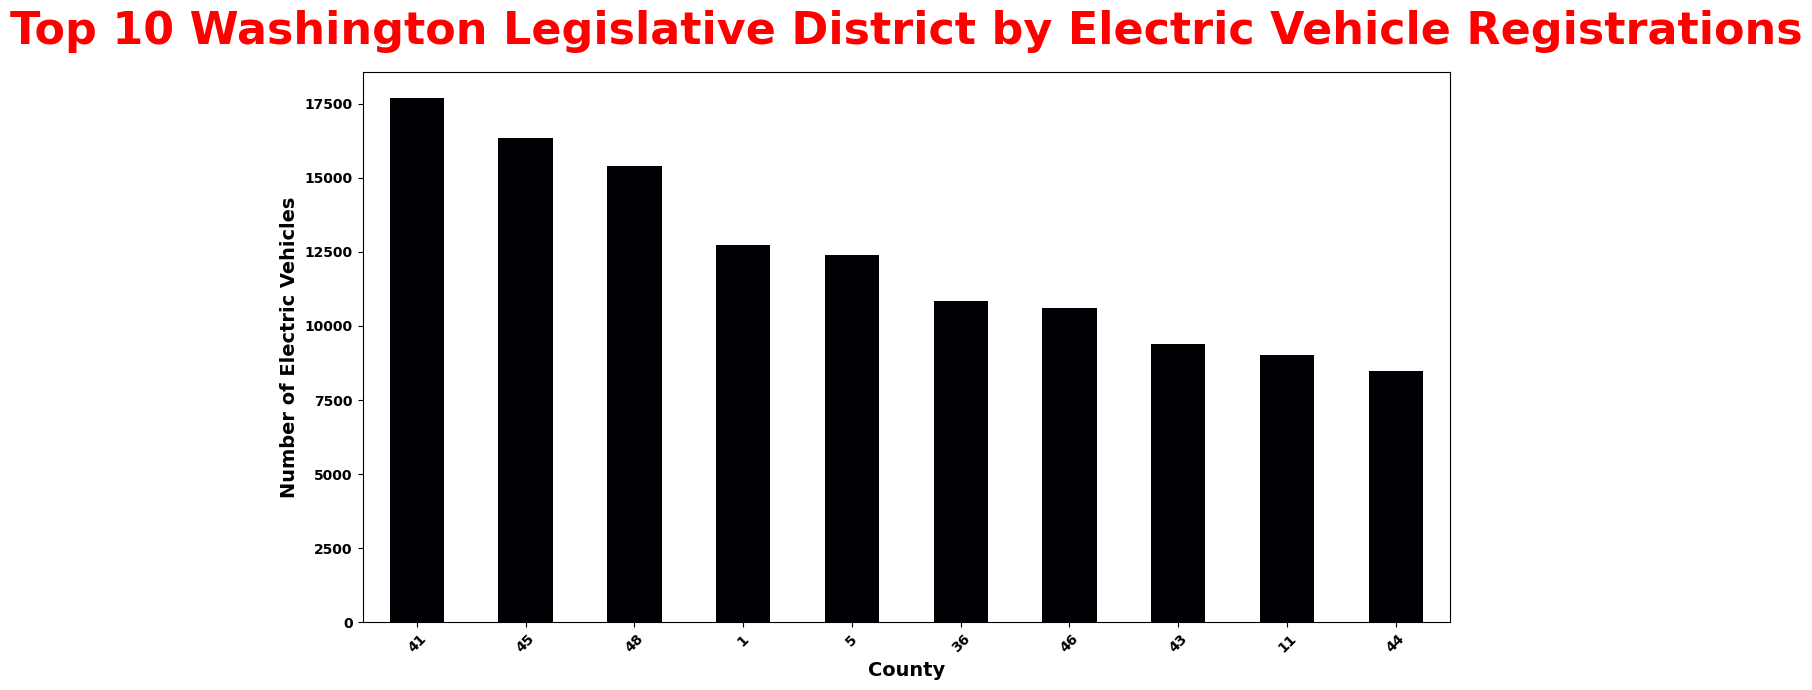

In [54]:
###EVs by legislative district
Legislative_District_counts = df["Legislative District"].value_counts().head(10)

Legislative_District_counts.plot(
    kind="bar",
    figsize=(12, 7),
    cmap='magma',                 # Colormap ('viridis', 'plasma', 'magma', 'coolwarm')
)
plt.title("Top 10 Washington Legislative District by Electric Vehicle Registrations",
    fontsize=32,
    fontweight="bold",
    color="red",
    pad=20
)
plt.xlabel('County', fontsize=14, fontweight="bold")
plt.ylabel('Number of Electric Vehicles', fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontweight="bold")
plt.yticks(rotation=0, fontweight="bold")
plt.tight_layout()
plt.show()

The legislative-district analysis shows how EV registrations are distributed across political constituencies. This could help identify districts where EV-related issues—such as charging infrastructure, electricity demand, incentives, and transportation policy—may be especially relevant. However, district population and household characteristics would be needed to compare relative adoption levels.

## 5 Vehicle Market Composition

This section examines the composition of registered electric vehicles by manufacturer, model, and electric-vehicle type. The analysis identifies the leading manufacturers and models and compares battery-electric vehicles with plug-in hybrid vehicles.

Because the dataset represents registered vehicles rather than annual sales, the results describe the composition of the registered electric-vehicle population—not current sales or purchases.

### 5.1 Leading Manufacturers

This analysis identifies the manufacturers with the largest numbers of registered electric vehicles and calculates their percentage shares of the dataset.

In [55]:
# Count vehicles by manufacturer
manufacturer_counts = (
    EV_Clean["Make"]
    .value_counts()
)

manufacturer_counts.head(10)

Make
TESLA        120899
CHEVROLET     19964
FORD          15983
NISSAN        15947
KIA           14586
TOYOTA        13526
BMW           12152
HYUNDAI       11966
RIVIAN         9537
VOLVO          7928
Name: count, dtype: int64

In [56]:
manufacturer_summary = pd.DataFrame({
    "Number of Vehicles": manufacturer_counts,
    "Percentage": (
        manufacturer_counts / len(EV_Clean) * 100
    ).round(1)
})

manufacturer_summary.head(10)

,Number of Vehicles,Percentage
Make,,
TESLA,120899,41.1
CHEVROLET,19964,6.8
FORD,15983,5.4
NISSAN,15947,5.4
KIA,14586,5.0
TOYOTA,13526,4.6
BMW,12152,4.1
HYUNDAI,11966,4.1
RIVIAN,9537,3.2


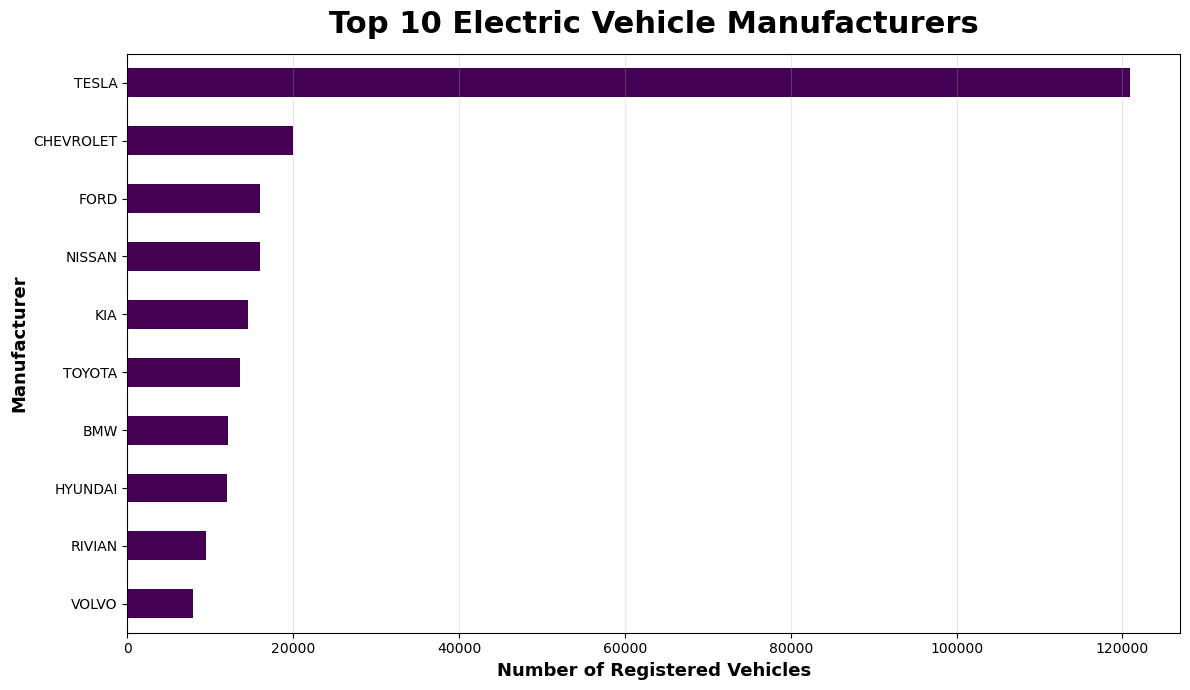

In [57]:
import matplotlib.pyplot as plt
import textwrap

top_manufacturers = (
    manufacturer_counts
    .head(10)
    .sort_values(ascending=True)
)

ax = top_manufacturers.plot(
    kind="barh",
    figsize=(12, 7),
    cmap="viridis",
    legend=False
)

plt.title(
    "Top 10 Electric Vehicle Manufacturers",
    fontsize=22,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Registered Vehicles",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Manufacturer",
    fontsize=13,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
##The manufacturer analysis indicates whether the registered electric-vehicle population is concentrated among a small number of companies. The leading manufacturer's percentage provides a particularly useful measure of market concentration.

tesla_count = manufacturer_counts.get(
    "TESLA",
    0
)

tesla_percentage = (
    tesla_count / len(EV_Clean) * 100
)

print("Tesla vehicles:", f"{tesla_count:,}")
print("Tesla percentage:", f"{tesla_percentage:.1f}%")


Tesla vehicles: 120,899
Tesla percentage: 41.1%


### 5.2 Most Common Models

This subsection identifies the most frequently registered electric-vehicle models. Because different manufacturers may use the same model name, manufacturer and model are combined before counting.

In [59]:
model_counts = (
    EV_Clean["Model"]
    .value_counts()
)

model_counts.head(15)

Model
MODEL Y              64984
MODEL 3              38980
LEAF                 13368
MODEL S               7808
BOLT EV               7530
IONIQ 5               7248
MODEL X               7152
MUSTANG MACH-E        6829
ID.4                  6319
R1S                   5538
RAV4 PRIME (PHEV)     5348
F-150                 4372
NIRO                  4356
VOLT                  4348
WRANGLER              4266
Name: count, dtype: int64

In [60]:
make_model_counts = (
    EV_Clean.groupby(["Make", "Model"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Number of Vehicles")
)

make_model_counts.head(10)

,Make,Model,Number of Vehicles
0,TESLA,MODEL Y,64984
1,TESLA,MODEL 3,38980
2,NISSAN,LEAF,13368
3,TESLA,MODEL S,7808
4,CHEVROLET,BOLT EV,7530
5,HYUNDAI,IONIQ 5,7248
6,TESLA,MODEL X,7152
7,FORD,MUSTANG MACH-E,6829
8,VOLKSWAGEN,ID.4,6319
9,RIVIAN,R1S,5538


In [61]:
top_models = make_model_counts.head(10).copy()

top_models["Vehicle"] = (
    top_models["Make"]
    + " "
    + top_models["Model"]
)

top_models[
    [
        "Vehicle",
        "Number of Vehicles"
    ]
]

,Vehicle,Number of Vehicles
0,TESLA MODEL Y,64984
1,TESLA MODEL 3,38980
2,NISSAN LEAF,13368
3,TESLA MODEL S,7808
4,CHEVROLET BOLT EV,7530
5,HYUNDAI IONIQ 5,7248
6,TESLA MODEL X,7152
7,FORD MUSTANG MACH-E,6829
8,VOLKSWAGEN ID.4,6319
9,RIVIAN R1S,5538


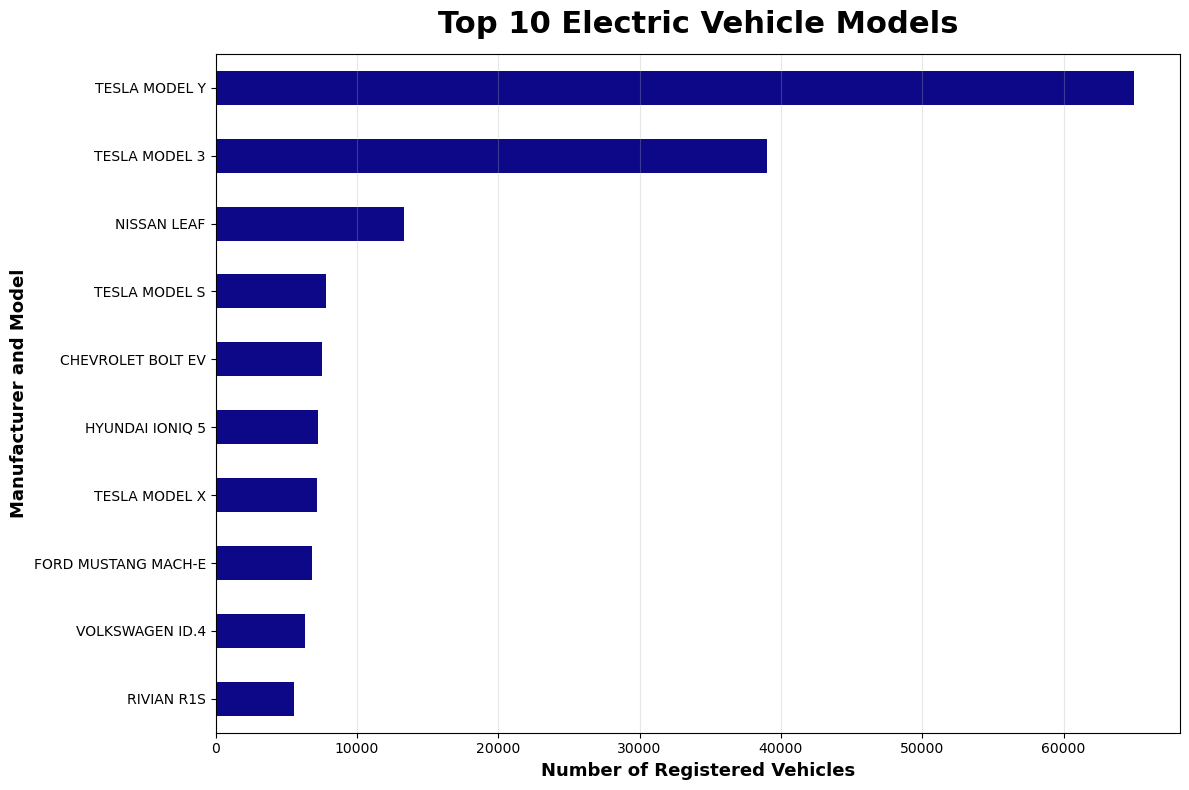

In [62]:
plot_models = (
    top_models
    .sort_values(
        "Number of Vehicles",
        ascending=True
    )
)

ax = plot_models.plot(
    kind="barh",
    x="Vehicle",
    y="Number of Vehicles",
    figsize=(12, 8),
    cmap="plasma",
    legend=False
)

# Wrap long model labels
wrapped_labels = [
    textwrap.fill(
        label.get_text(),
        width=25
    )
    for label in ax.get_yticklabels()
]

ax.set_yticklabels(wrapped_labels)

plt.title(
    "Top 10 Electric Vehicle Models",
    fontsize=22,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Registered Vehicles",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Manufacturer and Model",
    fontsize=13,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
leading_model_by_make = (
    make_model_counts.loc[
        make_model_counts
        .groupby("Make")["Number of Vehicles"]
        .idxmax()
    ]
    .sort_values(
        "Number of Vehicles",
        ascending=False
    )
    .reset_index(drop=True)
)

leading_model_by_make.head(15)

,Make,Model,Number of Vehicles
0,TESLA,MODEL Y,64984
1,NISSAN,LEAF,13368
2,CHEVROLET,BOLT EV,7530
3,HYUNDAI,IONIQ 5,7248
4,FORD,MUSTANG MACH-E,6829
5,VOLKSWAGEN,ID.4,6319
6,RIVIAN,R1S,5538
7,TOYOTA,RAV4 PRIME (PHEV),5348
8,KIA,NIRO,4356
9,JEEP,WRANGLER,4266


The model analysis shows whether vehicle registrations are concentrated not only among a few manufacturers but also among a small number of specific models. Combining manufacturer and model avoids incorrectly merging vehicles that happen to share similar model names.

### 5.3 BEV Versus PHEV Vehicles

Electric vehicles in the dataset are classified into two categories:

- Battery Electric Vehicles (BEVs), which operate entirely on electricity.
- Plug-in Hybrid Electric Vehicles (PHEVs), which combine an electric motor and battery with a gasoline-powered engine.

This subsection compares the number and percentage of registered vehicles in each category.

In [64]:
vehicle_type_counts = (
    EV_Clean["Electric Vehicle Type"]
    .value_counts()
)

vehicle_type_counts

Electric Vehicle Type
Battery Electric Vehicle (BEV)            237567
Plug-in Hybrid Electric Vehicle (PHEV)     56626
Name: count, dtype: int64

In [65]:
vehicle_type_summary = pd.DataFrame({
    "Number of Vehicles": vehicle_type_counts,
    "Percentage": (
        vehicle_type_counts
        / len(EV_Clean)
        * 100
    ).round(1)
})

vehicle_type_summary

,Number of Vehicles,Percentage
Electric Vehicle Type,,
Battery Electric Vehicle (BEV),237567,80.8
Plug-in Hybrid Electric Vehicle (PHEV),56626,19.2


In [66]:
vehicle_type_short = (
    EV_Clean["Electric Vehicle Type"]
    .replace({
        "Battery Electric Vehicle (BEV)": "BEV",
        "Plug-in Hybrid Electric Vehicle (PHEV)": "PHEV"
    })
)

vehicle_type_short_counts = (
    vehicle_type_short
    .value_counts()
)

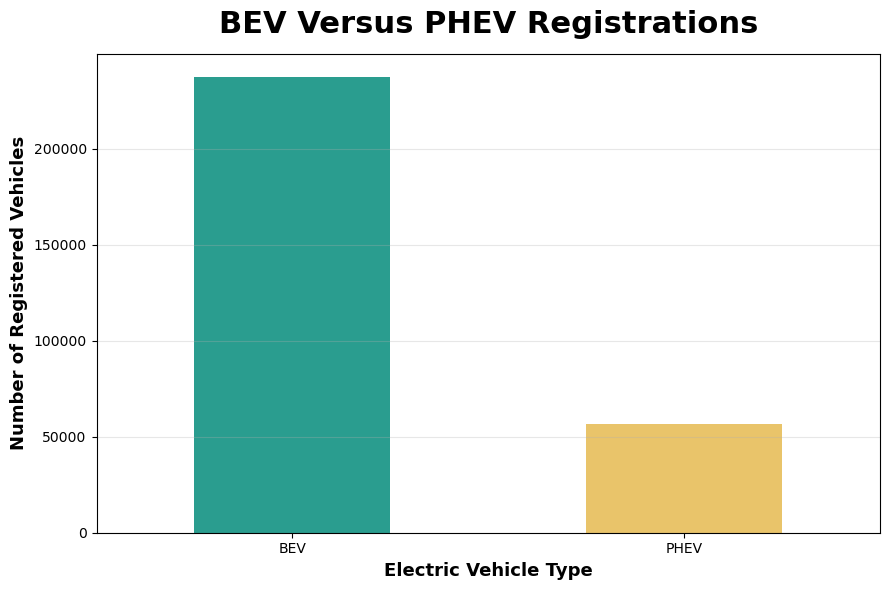

In [67]:
ax = vehicle_type_short_counts.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#2A9D8F", "#E9C46A"],
    legend=False
)

plt.title(
    "BEV Versus PHEV Registrations",
    fontsize=22,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Electric Vehicle Type",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Registered Vehicles",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

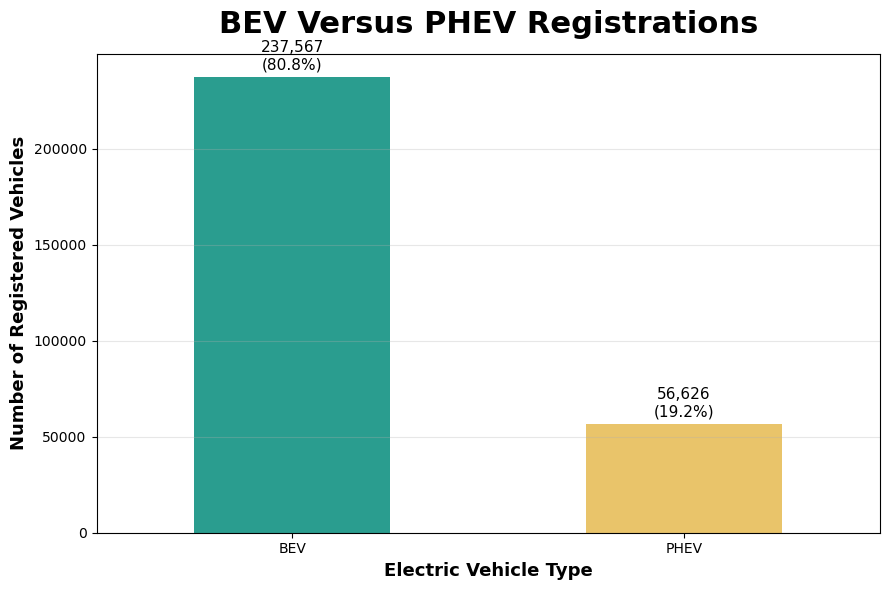

In [68]:
ax = vehicle_type_short_counts.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#2A9D8F", "#E9C46A"],
    legend=False
)

total_vehicles = vehicle_type_short_counts.sum()

for container in ax.containers:
    labels = [
        f"{int(value):,}\n({value / total_vehicles * 100:.1f}%)"
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=11
    )

plt.title(
    "BEV Versus PHEV Registrations",
    fontsize=22,
    fontweight="bold",
    pad=15
)

plt.xlabel("Electric Vehicle Type", fontsize=13, fontweight="bold")
plt.ylabel("Number of Registered Vehicles", fontsize=13, fontweight="bold")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Geographic Differences in Market Composition

This section examines whether the composition of registered electric vehicles differs across Washington counties. It identifies each county's leading manufacturer, compares battery-electric and plug-in hybrid shares, and calculates Tesla's share of registered electric vehicles.

The analysis uses percentages as well as counts because counties differ substantially in their total numbers of registered electric vehicles.

### 6.1 Leading Manufacturer by County

This subsection identifies the manufacturer with the largest number of registered electric vehicles in each Washington county. It also calculates the leading manufacturer's percentage of all registered electric vehicles in that county.

In [69]:
county_make_counts = (
    WA_EV_Clean
    .groupby(["County", "Make"])
    .size()
    .reset_index(name="Number of Vehicles")
)

county_make_counts.head()

,County,Make,Number of Vehicles
0,Adams,BMW,2
1,Adams,CADILLAC,2
2,Adams,CHEVROLET,9
3,Adams,CHRYSLER,1
4,Adams,FORD,12


In [70]:
County_Totals = (
    WA_EV_Clean["County"]
    .value_counts()
    .rename("County Total")
    .reset_index()
)

County_Totals.columns = [
    "County",
    "County Total"
]

County_Totals.head()

,County,County Total
0,King,141971
1,Snohomish,37128
2,Pierce,24578
3,Clark,18346
4,Thurston,10806


In [71]:
leading_make_by_county = (
    county_make_counts.loc[
        county_make_counts
        .groupby("County")["Number of Vehicles"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

In [72]:
leading_make_by_county = (
    leading_make_by_county
    .merge(
        County_Totals,
        on="County",
        how="left"
    )
)

leading_make_by_county["Market Share"] = (
    leading_make_by_county["Number of Vehicles"]
    / leading_make_by_county["County Total"]
    * 100
).round(1)

In [73]:
leading_make_by_county = (
    leading_make_by_county
    .sort_values(
        "County Total",
        ascending=False
    )
)

leading_make_by_county.head(10)

,County,Make,Number of Vehicles,County Total,Market Share
16,King,TESLA,62184,141971,43.8
30,Snohomish,TESLA,17558,37128,47.3
26,Pierce,TESLA,9579,24578,39.0
5,Clark,TESLA,7355,18346,40.1
33,Thurston,TESLA,3412,10806,31.6
17,Kitsap,TESLA,2994,10185,29.4
31,Spokane,TESLA,3045,8503,35.8
36,Whatcom,TESLA,2115,7357,28.7
2,Benton,TESLA,1966,4382,44.9
28,Skagit,TESLA,1125,3504,32.1


In [74]:
print(County_Totals.columns.tolist())
print(leading_make_by_county.columns.tolist())

['County', 'County Total']
['County', 'Make', 'Number of Vehicles', 'County Total', 'Market Share']


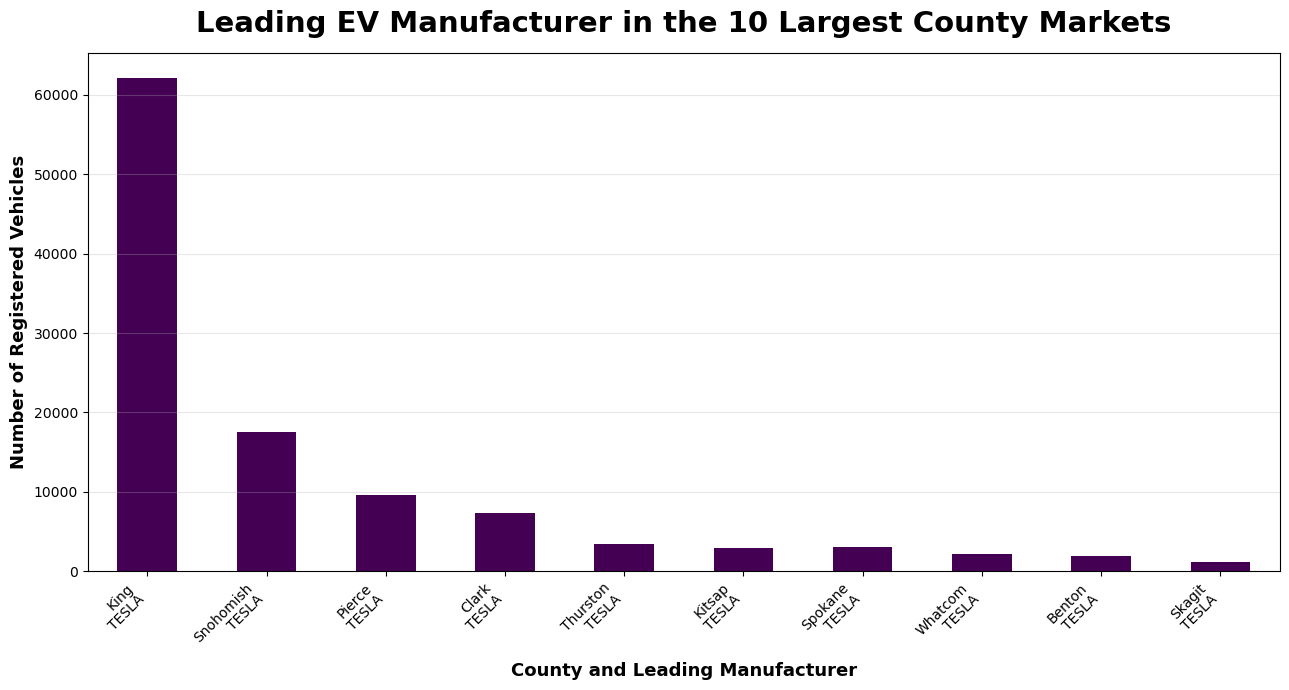

In [75]:
import matplotlib.pyplot as plt
import textwrap

plot_leading_make = (
    leading_make_by_county
    .head(10)
    .copy()
)

plot_leading_make["County and Manufacturer"] = (
    plot_leading_make["County"]
    + "\n"
    + plot_leading_make["Make"]
)

ax = plot_leading_make.plot(
    kind="bar",
    x="County and Manufacturer",
    y="Number of Vehicles",
    figsize=(13, 7),
    cmap="viridis",
    legend=False
)

plt.title(
    "Leading EV Manufacturer in the 10 Largest County Markets",
    fontsize=21,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "County and Leading Manufacturer",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Registered Vehicles",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The leading-manufacturer analysis shows whether the same company dominates registrations across Washington or whether manufacturer preferences differ geographically. The analysis is restricted to the ten largest county EV markets in the visualization so that very small counties do not receive the same visual emphasis as counties containing thousands of registered vehicles.

### 6.2 BEV and PHEV Shares by County

This subsection compares the percentage of battery-electric vehicles and plug-in hybrid electric vehicles within each county. Percentages are more informative than raw counts for this comparison because county registration totals vary considerably.

In [76]:
WA_EV_Clean["Vehicle Type Short"] = (
    WA_EV_Clean["Electric Vehicle Type"]
    .replace({
        "Battery Electric Vehicle (BEV)": "BEV",
        "Plug-in Hybrid Electric Vehicle (PHEV)": "PHEV"
    })
)

In [77]:
top_10_counties = (
    WA_EV_Clean["County"]
    .value_counts()
    .head(10)
    .index
)

top_10_counties

Index(['King', 'Snohomish', 'Pierce', 'Clark', 'Thurston', 'Kitsap', 'Spokane',
       'Whatcom', 'Benton', 'Skagit'],
      dtype='string', name='County')

In [78]:
county_vehicle_type_share = (
    pd.crosstab(
        WA_EV_Clean["County"],
        WA_EV_Clean["Vehicle Type Short"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

county_vehicle_type_share.head()

Vehicle Type Short,BEV,PHEV
County,,
Adams,79.9,20.1
Asotin,68.0,32.0
Benton,75.9,24.1
Chelan,81.5,18.5
Clallam,71.7,28.3


In [79]:
top_county_type_share = (
    county_vehicle_type_share
    .reindex(top_10_counties)
)

top_county_type_share

Vehicle Type Short,BEV,PHEV
County,,
King,82.9,17.1
Snohomish,84.5,15.5
Pierce,78.7,21.3
Clark,77.5,22.5
Thurston,77.6,22.4
Kitsap,77.4,22.6
Spokane,73.3,26.7
Whatcom,76.7,23.3
Benton,75.9,24.1


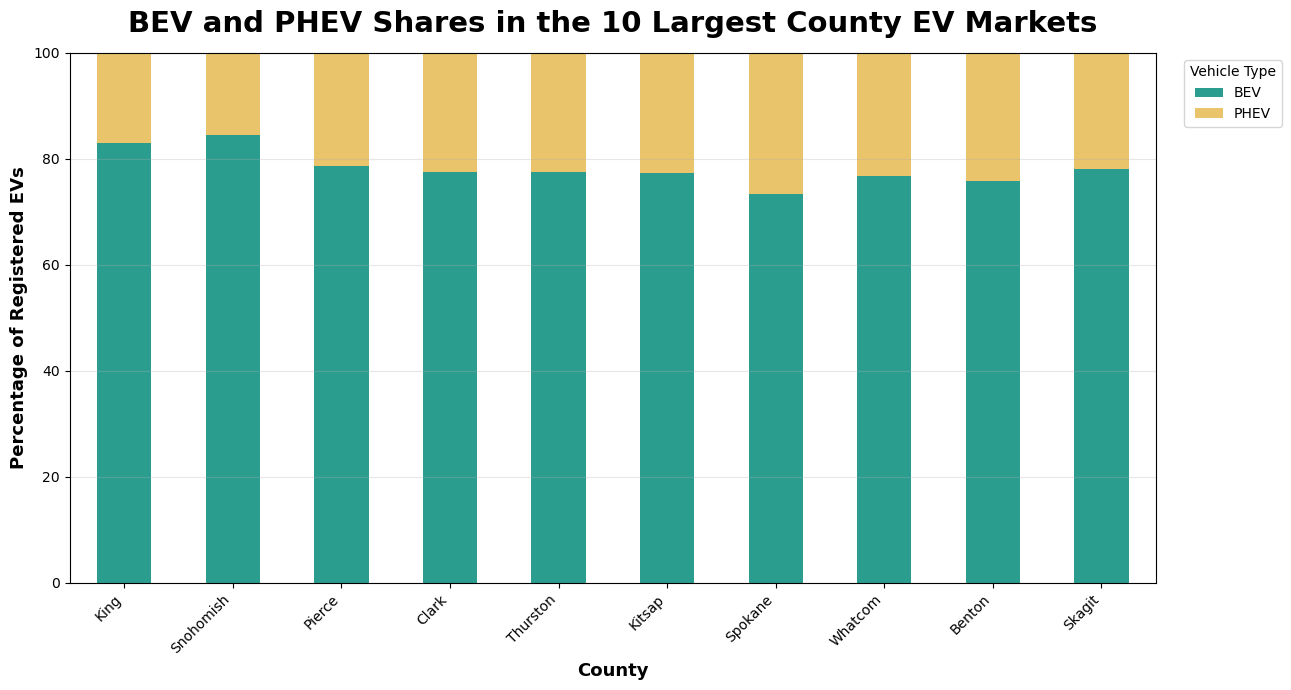

In [80]:
ax = top_county_type_share.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7),
    color={
        "BEV": "#2A9D8F",
        "PHEV": "#E9C46A"
    }
)

plt.title(
    "BEV and PHEV Shares in the 10 Largest County EV Markets",
    fontsize=21,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "County",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Percentage of Registered EVs",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.legend(
    title="Vehicle Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
county_vehicle_type_share.sort_values(
    "BEV",
    ascending=False
).head(10)

Vehicle Type Short,BEV,PHEV
County,,
Snohomish,84.5,15.5
Columbia,83.3,16.7
King,82.9,17.1
Chelan,81.5,18.5
Kittitas,81.4,18.6
Skamania,81.0,19.0
Douglas,80.4,19.6
Franklin,80.3,19.7
Adams,79.9,20.1


### 6.3 Tesla Market Share by County

Tesla's county market share is calculated as the number of registered Tesla vehicles divided by the total numbe of registered electric vehicles in that county. The calculation describes Tesla's share of the registered EV population rather than its share of annual vehicle sales.

In [88]:
WA_EV_Clean["Tesla"] = (
    WA_EV_Clean["Make"]
    .eq("TESLA")
)

In [90]:
tesla_by_county = (
    WA_EV_Clean
    .groupby("County")
    .agg(
        Tesla_Vehicles=("Tesla", "sum"),
        Total_EVs=("Tesla", "size")
    )
    .reset_index()
)

In [91]:
tesla_by_county["Tesla Market Share"] = (
    tesla_by_county["Tesla_Vehicles"]
    / tesla_by_county["Total_EVs"]
    * 100
).round(1)

In [92]:
tesla_by_county = (
    tesla_by_county
    .sort_values(
        "Total_EVs",
        ascending=False
    )
)

tesla_by_county.head(10)

,County,Tesla_Vehicles,Total_EVs,Tesla Market Share
16,King,62184,141971,43.8
30,Snohomish,17558,37128,47.3
26,Pierce,9579,24578,39.0
5,Clark,7355,18346,40.1
33,Thurston,3412,10806,31.6
17,Kitsap,2994,10185,29.4
31,Spokane,3045,8503,35.8
36,Whatcom,2115,7357,28.7
2,Benton,1966,4382,44.9
28,Skagit,1125,3504,32.1


In [93]:
tesla_by_county = (
    tesla_by_county
    .sort_values(
        "Total_EVs",
        ascending=False
    )
)

tesla_by_county.head(10)

,County,Tesla_Vehicles,Total_EVs,Tesla Market Share
16,King,62184,141971,43.8
30,Snohomish,17558,37128,47.3
26,Pierce,9579,24578,39.0
5,Clark,7355,18346,40.1
33,Thurston,3412,10806,31.6
17,Kitsap,2994,10185,29.4
31,Spokane,3045,8503,35.8
36,Whatcom,2115,7357,28.7
2,Benton,1966,4382,44.9
28,Skagit,1125,3504,32.1


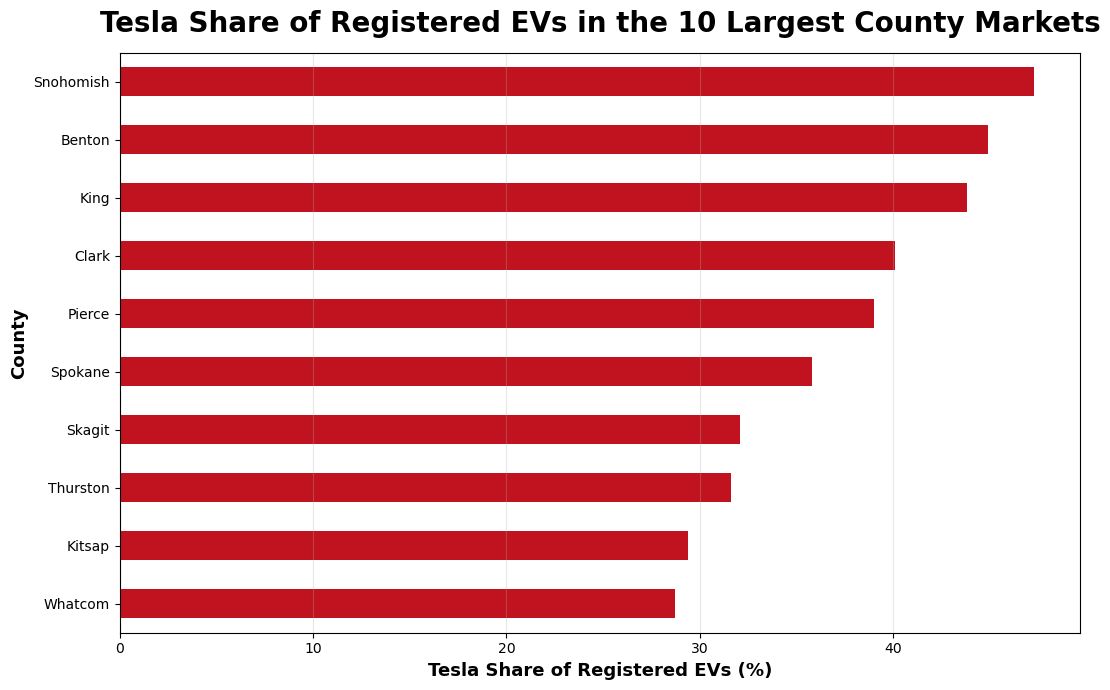

In [94]:
tesla_top_counties = (
    tesla_by_county
    .head(10)
    .sort_values(
        "Tesla Market Share",
        ascending=True
    )
)

ax = tesla_top_counties.plot(
    kind="barh",
    x="County",
    y="Tesla Market Share",
    figsize=(11, 7),
    color="#C1121F",
    legend=False
)

plt.title(
    "Tesla Share of Registered EVs in the 10 Largest County Markets",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Tesla Share of Registered EVs (%)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "County",
    fontsize=13,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

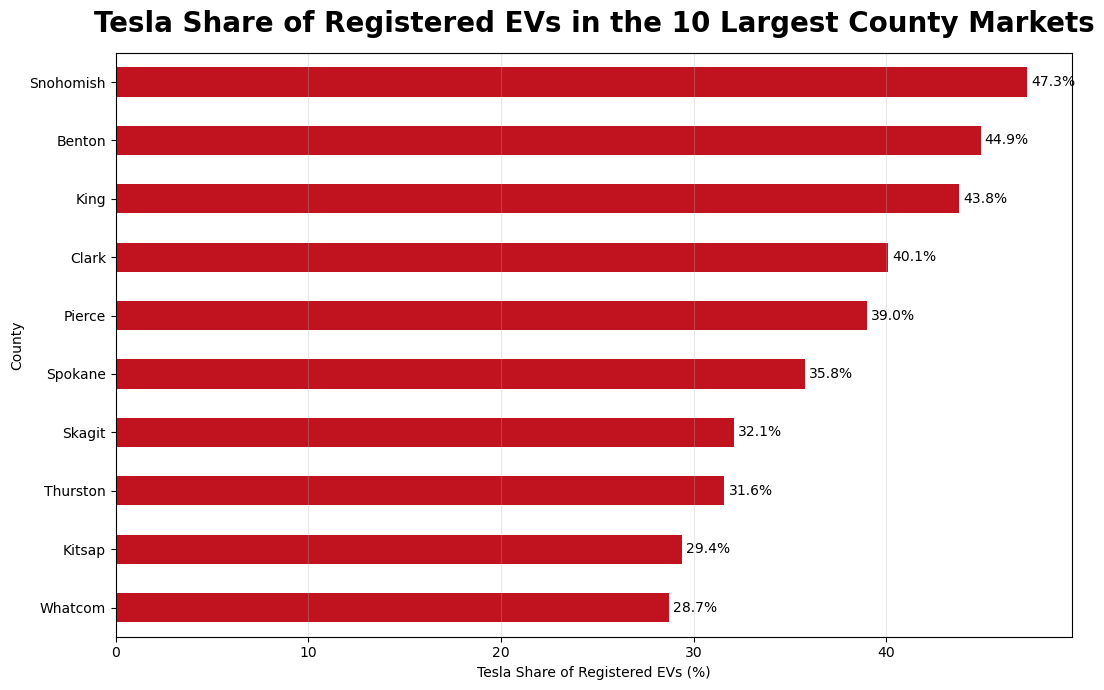

In [95]:
ax = tesla_top_counties.plot(
    kind="barh",
    x="County",
    y="Tesla Market Share",
    figsize=(11, 7),
    color="#C1121F",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title(
    "Tesla Share of Registered EVs in the 10 Largest County Markets",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Tesla Share of Registered EVs (%)")
plt.ylabel("County")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
tesla_large_counties = (
    tesla_by_county[
        tesla_by_county["Total_EVs"] >= 500
    ]
    .sort_values(
        "Tesla Market Share",
        ascending=False
    )
)

tesla_large_counties.head(10)

,County,Tesla_Vehicles,Total_EVs,Tesla Market Share
10,Franklin,726,1347,53.9
30,Snohomish,17558,37128,47.3
12,Grant,576,1234,46.7
2,Benton,1966,4382,44.9
38,Yakima,949,2166,43.8
16,King,62184,141971,43.8
18,Kittitas,505,1187,42.5
8,Douglas,277,684,40.5
5,Clark,7355,18346,40.1
26,Pierce,9579,24578,39.0


In [ ]:
Tesla's share varies across county EV markets. Restricting the comparison to counties with at least 500 registered electric vehicles reduces the possibility that unusually high percentages are driven by only a small number of vehicles. The results demonstrate geographic variation in vehicle composition but do not establish why Tesla is more prevalent in some counties than others.

Tesla's share varies across county EV markets. Restricting the comparison to counties with at least 500 registered electric vehicles reduces the possibility that unusually high percentages are driven by only a small number of vehicles. The results demonstrate geographic variation in vehicle composition but do not establish why Tesla is more prevalent in some counties than others.

Together, these findings show that Washington's EV market is geographically uneven not only in its total number of registered vehicles but also in its manufacturer and vehicle-type composition.